In [3]:
# 🔷 1. Import Libraries & Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [9]:
# Load dataset
df = pd.read_csv('/content/stores_sales_forecasting.csv', encoding='latin1')

In [10]:
# View data
print(df.head())
print(df.info())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
3       6  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   
4      11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   

     Customer Name   Segment        Country             City  ... Postal Code  \
0      Claire Gute  Consumer  United States        Henderson  ...       42420   
1      Claire Gute  Consumer  United States        Henderson  ...       42420   
2   Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...       33311   
3  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   
4  Brosina Hoffman  Consumer  United States      Los Angeles  ...       90032   

   Region       Product ID

In [15]:
# 📊 Convert Date Column

df['Order Date'] = pd.to_datetime(df['Order Date'])

In [18]:
df.set_index('Order Date', inplace=True)

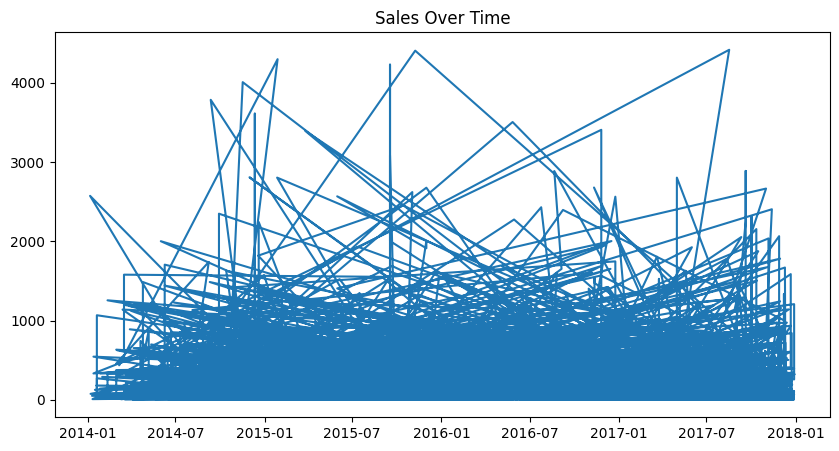

In [19]:
# 📉 Plot Sales Trend

plt.figure(figsize=(10,5))
plt.plot(df['Sales'])
plt.title("Sales Over Time")
plt.show()

/tmp/ipykernel_13682/1317049145.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['Sales'].resample('M').mean().plot(title="Monthly Sales")


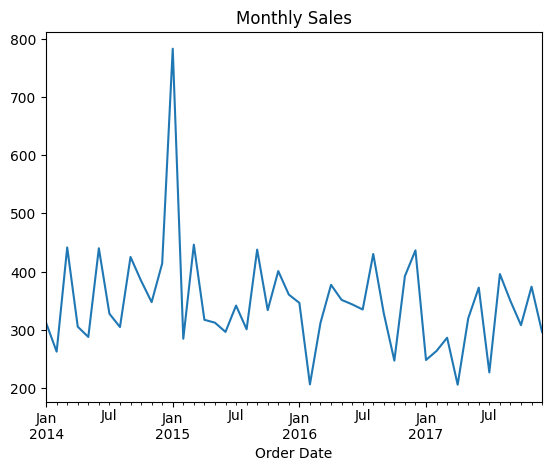

In [20]:
# 🔁 Check Seasonality (Monthly)

df['Sales'].resample('M').mean().plot(title="Monthly Sales")
plt.show()

In [21]:
# 🔍 Missing Values

print(df.isnull().sum())



Row ID           0
Order ID         0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [24]:
# ✅ Handle Missing Values

df = df.fillna(method='ffill')  # forward fill


/tmp/ipykernel_13682/1862156074.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')  # forward fill


In [25]:
# Feature Engineering

df['year'] = df.index.year
df['month'] = df.index.month
df['day'] = df.index.day
df['weekday'] = df.index.weekday

In [26]:
# Create Lag Features (important for forecasting)

df['lag_1'] = df['Sales'].shift(1)
df['lag_7'] = df['Sales'].shift(7)

In [27]:
df = df.dropna()

In [28]:
# Train-Test Split (Time-Based)

train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

In [31]:
X_train = train.drop(['Sales', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name'], axis=1)
y_train = train['Sales']

X_test = test.drop(['Sales', 'Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name'], axis=1)
y_test = test['Sales']

In [32]:
# Apply Model (Linear Regression)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred = model.predict(X_test)

In [34]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 297.40300274758266
RMSE: 534.5748644070992
R2 Score: 0.16706531576388584


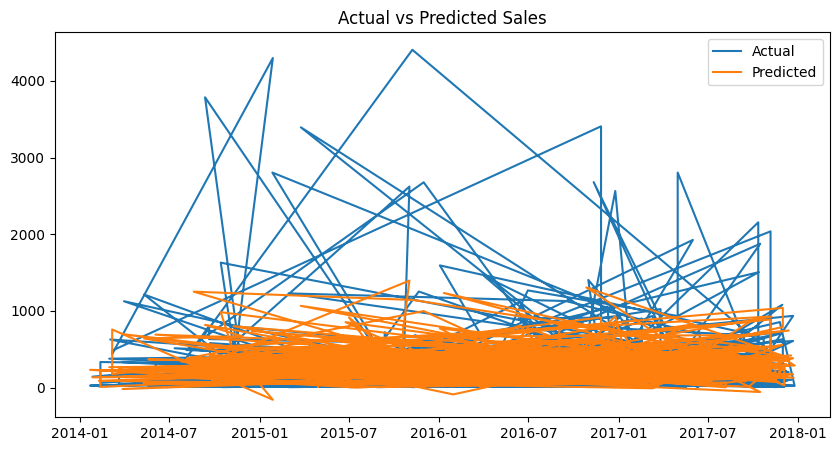

In [35]:
# . Visualization of Results

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [36]:
# ARIMA Model

from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train['Sales'], order=(5,1,0))
model_arima_fit = model_arima.fit()

forecast = model_arima_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

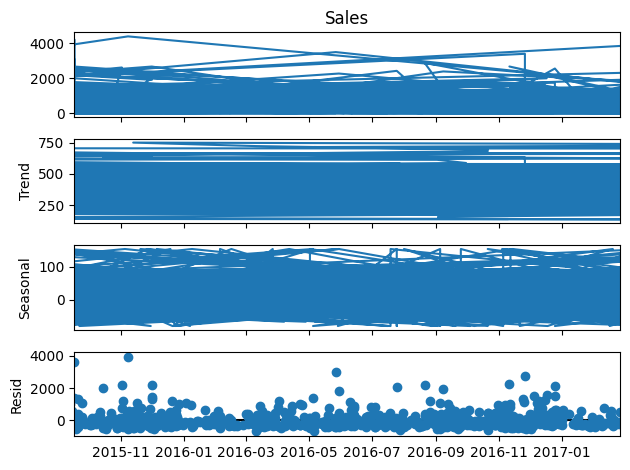

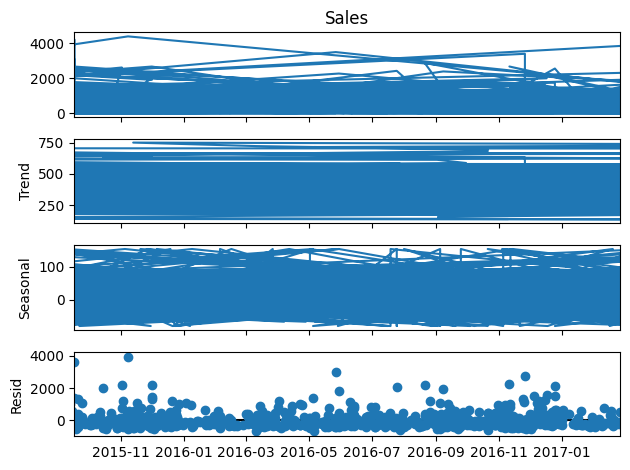

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df['Sales'], model='additive', period=30)
result.plot()

In [39]:
# Find best parameters

!pip install pmdarima
from pmdarima import auto_arima

auto_model = auto_arima(df['Sales'], seasonal=False, trace=True)
print(auto_model.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.3 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=inf, Time=2.78 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=33128.602, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=32829.135, Time=0.11 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=32929.404, Time=1.23 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=32691.272, Time=0.25 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=32588.479, Time=0.47 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=32549.272, Time=0.75 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=32527.966, Time=0.69 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=4.43 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=inf, Time=2.37 sec
 ARIMA(5,0,0)(0,0,0)[0] intercept   : AIC=32292.290, Time=0.77 sec
 ARIMA(4,0,0)(0,0,0)[0] intercept   : AIC=32290.638, Time=0.50 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=32288.748, Time=0.41 sec
 ARIMA(2,0,0)(0,0,0)[0]

In [41]:
df['DayOfWeek'] = df.index.dayofweek
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x>=5 else 0)

<Axes: >

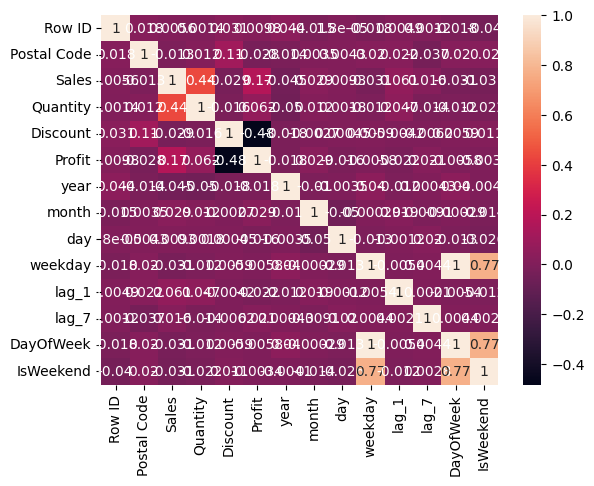

In [43]:
import seaborn as sns

sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)

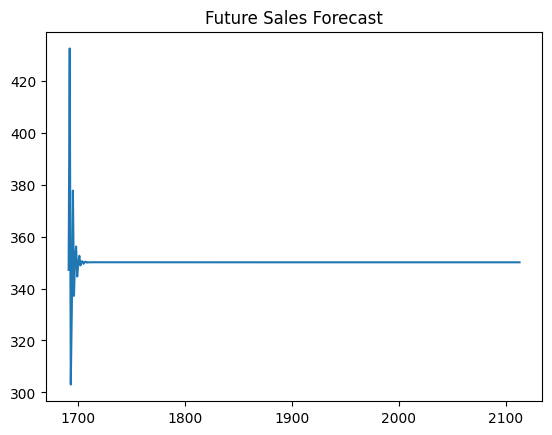

In [44]:
# Future Forecast Visualization

plt.plot(forecast)
plt.title("Future Sales Forecast")
plt.show()